# 06 - Backtesting: Portfolio Multi-Factor con Rebalanceo

**Capítulo**: 06 - Multi-Factor

**Objetivo**: Simular portfolio con rebalanceo mensual, medir performance vs benchmark (SPY).

---

In [1]:
import sys
sys.path.insert(0, '../..')

import pandas as pd
import numpy as np
from curso.lib.data import download_historical, download_multiple
from curso.lib.indicators import sma, rsi, atr
from curso.lib.reporting import plot_equity_curve

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
print('Setup completado ✓')

Setup completado ✓


## 1. Datos

In [2]:
UNIVERSE = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'JNJ', 'PFE', 'UNH', 'JPM', 'BAC', 'V',
            'XOM', 'CVX', 'PG', 'KO', 'WMT', 'CAT', 'HON', 'ABBV', 'GS', 'COP']
TOP_K = 5
REBALANCE_FREQ = 'MS'  # Month Start

datos = download_multiple(UNIVERSE)
benchmark = download_historical('SPY')
print(f'Activos: {len(datos)}, Benchmark: SPY')

Activos: 20, Benchmark: SPY


## 2. Scoring function

In [3]:
def compute_scores(datos, date, lookback=252):
    """Calcula scores para todos los activos a una fecha dada."""
    scores = {}
    
    for ticker, df in datos.items():
        # Filtrar hasta la fecha
        hist = df[df.index <= date].tail(lookback)
        if len(hist) < 50:
            continue
        
        # Momentum: RSI + ROC(20)
        rsi_val = rsi(hist, length=14).iloc[-1] if len(hist) > 14 else 50
        roc_val = (hist['Close'].iloc[-1] / hist['Close'].iloc[-20] - 1) * 100 if len(hist) > 20 else 0
        
        # Trend: distance to SMA(200)
        sma_200 = sma(hist, length=min(200, len(hist)-1)).iloc[-1]
        trend = (hist['Close'].iloc[-1] / sma_200 - 1) * 100 if sma_200 > 0 else 0
        
        # Volatility: inverse ATR%
        atr_val = atr(hist, length=14).iloc[-1] if len(hist) > 14 else 1
        vol = atr_val / hist['Close'].iloc[-1] * 100
        
        scores[ticker] = {
            'momentum': (rsi_val + max(0, roc_val)) / 2,
            'trend': trend,
            'volatility': -vol  # Negative so higher = less volatile
        }
    
    if not scores:
        return []
    
    scores_df = pd.DataFrame(scores).T
    
    # Normalize each factor to [0, 1]
    for col in scores_df.columns:
        mn, mx = scores_df[col].min(), scores_df[col].max()
        if mx > mn:
            scores_df[col] = (scores_df[col] - mn) / (mx - mn)
        else:
            scores_df[col] = 0.5
    
    # Composite score
    scores_df['total'] = 0.4 * scores_df['momentum'] + 0.4 * scores_df['trend'] + 0.2 * scores_df['volatility']
    
    return scores_df.nlargest(TOP_K, 'total').index.tolist()

## 3. Simulación de portfolio con rebalanceo

In [4]:
# Generar fechas de rebalanceo
all_dates = sorted(set.intersection(*[set(df.index) for df in datos.values()]))
rebalance_dates = pd.DatetimeIndex(all_dates).to_series().resample(REBALANCE_FREQ).first().dropna().values
rebalance_dates = [d for d in rebalance_dates if d >= all_dates[252]]  # Skip first year

# Simular
CAPITAL = 10_000
portfolio_value = [CAPITAL]
portfolio_dates = [rebalance_dates[0]]
holdings = []

for i, date in enumerate(rebalance_dates[:-1]):
    next_date = rebalance_dates[i + 1]
    
    # Select top-K
    selected = compute_scores(datos, date)
    if not selected:
        portfolio_value.append(portfolio_value[-1])
        portfolio_dates.append(next_date)
        continue
    
    # Equal weight returns
    period_returns = []
    for ticker in selected:
        df = datos[ticker]
        start_price = df[df.index >= date]['Close'].iloc[0] if len(df[df.index >= date]) > 0 else None
        end_price = df[df.index >= next_date]['Close'].iloc[0] if len(df[df.index >= next_date]) > 0 else None
        if start_price and end_price:
            period_returns.append(end_price / start_price - 1)
    
    avg_return = np.mean(period_returns) if period_returns else 0
    new_value = portfolio_value[-1] * (1 + avg_return)
    portfolio_value.append(new_value)
    portfolio_dates.append(next_date)
    holdings.append((date, selected))

portfolio_series = pd.Series(portfolio_value, index=portfolio_dates)
print(f'Portfolio final: ${portfolio_value[-1]:,.0f} (de ${CAPITAL:,.0f})')
print(f'Retorno total: {(portfolio_value[-1]/CAPITAL - 1)*100:.1f}%')
print(f'Rebalanceos: {len(rebalance_dates)}')

Portfolio final: $14,164 (de $10,000)
Retorno total: 41.6%
Rebalanceos: 48


## 4. Comparación vs Benchmark

Portfolio Multi-Factor: 41.6%
Benchmark (SPY):        75.9%
Alpha:                  -34.3%


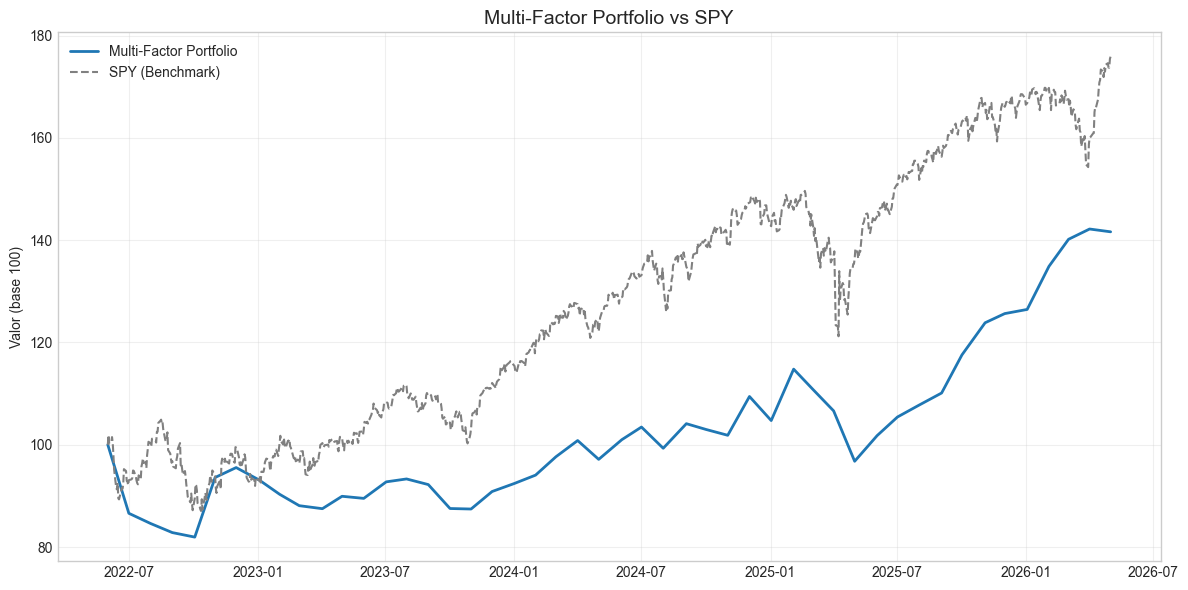

In [5]:
# Benchmark (SPY) en el mismo período
bm_start = benchmark[benchmark.index >= portfolio_dates[0]]['Close'].iloc[0]
bm_end = benchmark[benchmark.index <= portfolio_dates[-1]]['Close'].iloc[-1]
bm_return = (bm_end / bm_start - 1) * 100

port_return = (portfolio_value[-1] / CAPITAL - 1) * 100

print(f'Portfolio Multi-Factor: {port_return:.1f}%')
print(f'Benchmark (SPY):        {bm_return:.1f}%')
print(f'Alpha:                  {port_return - bm_return:.1f}%')

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(portfolio_dates, [v/CAPITAL*100 for v in portfolio_value], linewidth=2, label='Multi-Factor Portfolio')

# Normalize benchmark
bm_filtered = benchmark[(benchmark.index >= portfolio_dates[0]) & (benchmark.index <= portfolio_dates[-1])]
bm_norm = bm_filtered['Close'] / bm_filtered['Close'].iloc[0] * 100
ax.plot(bm_norm.index, bm_norm.values, linewidth=1.5, linestyle='--', label='SPY (Benchmark)', color='gray')

ax.set_title('Multi-Factor Portfolio vs SPY', fontsize=14)
ax.set_ylabel('Valor (base 100)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Conclusiones

In [6]:
print('''
CONCLUSIONES
============
1. Alpha vs benchmark: [positivo/negativo]
2. Diversificación: [evaluar rotación de activos]
3. Drawdown del portfolio: [evaluar]
4. Factor que más contribuye: [momentum/trend/volatility]
5. DECISIÓN: [aprobar / ajustar pesos / cambiar factores]
''')


CONCLUSIONES
1. Alpha vs benchmark: [positivo/negativo]
2. Diversificación: [evaluar rotación de activos]
3. Drawdown del portfolio: [evaluar]
4. Factor que más contribuye: [momentum/trend/volatility]
5. DECISIÓN: [aprobar / ajustar pesos / cambiar factores]

